# 03 — Optimization: Gradient Descent, Convexity & Constrained Optimization

**Book reference:** *Mathematics for Machine Learning* (Deisenroth, Faisal, Ong) — §7.1–7.3, pp.227–246 (Optimization Using Gradient Descent, Constrained Optimization and Lagrange Multipliers, Convex Optimization)

Part of the Calculus subchapter of the 6-month ML Engineer prep plan.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## Gradient descent: walk downhill, one step at a time

From the first notebook: the gradient points toward steepest ascent. Gradient descent just walks the opposite way:

```
x_{t+1} = x_t - lr * ∇f(x_t)
```

The learning rate `lr` controls step size, and it's the single most consequential hyperparameter in this whole update rule. Let's see why, on a simple convex bowl `f(x, y) = x² + 2y²`.

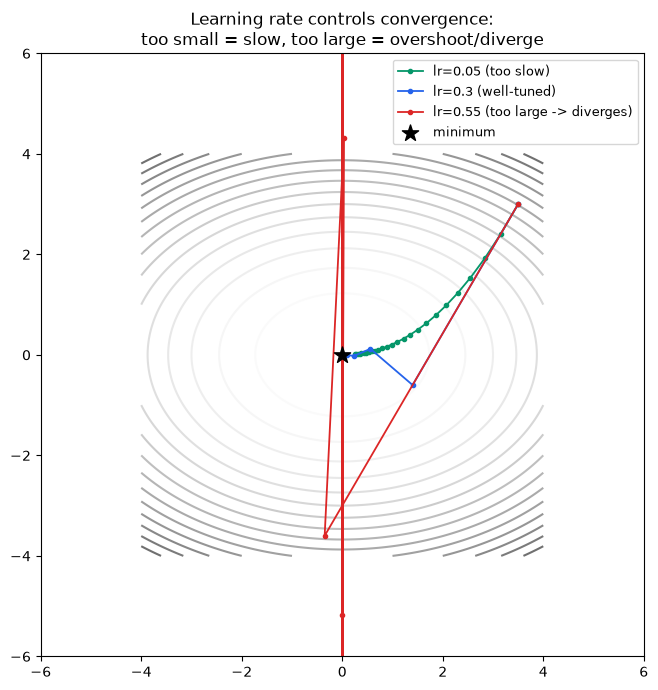

In [2]:
def f(xy):
    x, y = xy
    return x**2 + 2*y**2

def grad_f(xy):
    x, y = xy
    return np.array([2*x, 4*y])

def gradient_descent(start, lr, steps=25):
    path = [np.array(start, dtype=float)]
    p = np.array(start, dtype=float)
    for _ in range(steps):
        p = p - lr * grad_f(p)
        path.append(p.copy())
        if np.any(np.abs(p) > 50):   # diverging, stop early
            break
    return np.array(path)

def visualize_gd_trajectories(savepath: Path = None):
    xc = np.linspace(-4, 4, 200)
    yc = np.linspace(-4, 4, 200)
    Xc, Yc = np.meshgrid(xc, yc)
    Zc = Xc**2 + 2*Yc**2

    lrs = {"lr=0.05 (too slow)": 0.05, "lr=0.3 (well-tuned)": 0.3,
           "lr=0.55 (too large -> diverges)": 0.55}
    colors = {"lr=0.05 (too slow)": "#059669", "lr=0.3 (well-tuned)": "#2563eb",
              "lr=0.55 (too large -> diverges)": "#dc2626"}

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.contour(Xc, Yc, Zc, levels=15, cmap="Greys", alpha=0.6)
    for label, lr in lrs.items():
        path = gradient_descent([3.5, 3.0], lr, steps=25)
        ax.plot(path[:, 0], path[:, 1], marker="o", markersize=3, linewidth=1.3,
                color=colors[label], label=label)
    ax.scatter([0], [0], color="black", marker="*", s=150, zorder=5, label="minimum")
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.set_aspect("equal")
    ax.legend(fontsize=9, loc="upper right")
    ax.set_title("Learning rate controls convergence:\ntoo small = slow, too large = overshoot/diverge")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_gd_trajectories(FIG_DIR / "gd_trajectories.png")

Green (`lr=0.05`) crawls toward the minimum — stable but wastes steps. Blue (`lr=0.3`) converges cleanly in just a few steps. Red (`lr=0.55`) overshoots on every step and diverges outright along the steeper `y` direction.

This isn't just a toy example — the exact instability you see for the red trajectory (`lr` too large relative to the curvature of the loss surface) is why training loss occasionally spikes to `NaN` with too-aggressive learning rates, and it's the mechanical reason learning rate warmup and schedules exist: start small while the loss surface is poorly understood, increase once training stabilizes, then decay as you approach the minimum and want to stop overshooting it.

**Momentum and Adam, briefly:** plain SGD uses only the current gradient. Momentum adds a running average of past gradients (dampens oscillation in high-curvature directions, like the red trajectory above). Adam additionally adapts the effective learning rate per-parameter based on the recent magnitude of that parameter's gradients — both are, at their core, still trying to solve exactly the instability shown above, just more cleverly than a fixed global learning rate.

## Convexity: the property that makes "gradient descent finds the optimum" a guarantee

A function is **convex** if the line segment between any two points on its graph lies above (or on) the graph — equivalently, its curvature never bends the "wrong way." The huge practical consequence: **for a convex function, any local minimum is automatically the global minimum.**

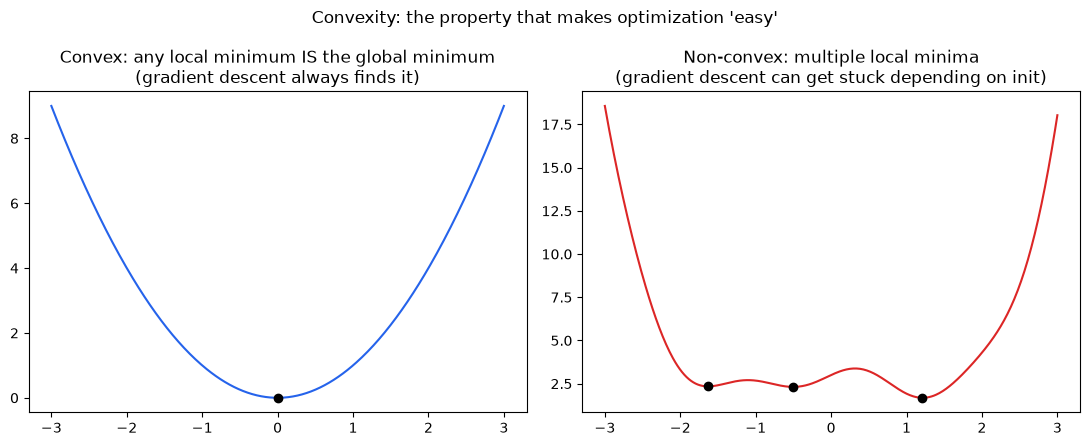

In [3]:
def visualize_convex_vs_nonconvex(savepath: Path = None):
    from scipy.signal import argrelextrema
    x = np.linspace(-3, 3, 400)
    convex = x**2
    nonconvex = 0.3*x**4 - x**2 + 0.5*np.sin(4*x) + 3

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].plot(x, convex, color="#2563eb")
    axes[0].set_title("Convex: any local minimum IS the global minimum\n(gradient descent always finds it)")
    axes[0].scatter([0], [0], color="black", zorder=5)

    axes[1].plot(x, nonconvex, color="#dc2626")
    minima_idx = argrelextrema(nonconvex, np.less)[0]
    axes[1].scatter(x[minima_idx], nonconvex[minima_idx], color="black", zorder=5)
    axes[1].set_title("Non-convex: multiple local minima\n(gradient descent can get stuck depending on init)")

    fig.suptitle("Convexity: the property that makes optimization 'easy'")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_convex_vs_nonconvex(FIG_DIR / "convex_vs_nonconvex.png")

Linear regression and logistic regression have convex loss surfaces — that's why their "solve to convergence" behavior is so reliable and why closed-form or simple gradient descent solutions work well.

**Neural network loss surfaces are almost never convex.** In high dimensions, though, the practically dominant obstacle isn't usually "bad" local minima (most local minima in an overparameterized network turn out to be nearly as good as the global one) — it's **saddle points**, where the gradient is zero but the point is a minimum along some directions and a maximum along others. This is one of the more nuanced, senior-level interview points: "why doesn't non-convexity doom deep learning in practice?"

## Constrained optimization and Lagrange multipliers

Sometimes you don't want to minimize `f(x)` freely — you want to minimize it *subject to* a constraint, `g(x) = 0`. The classic method: introduce a **Lagrange multiplier** `λ` and optimize the Lagrangian `L(x, λ) = f(x) - λg(x)`.

The key geometric insight: **at the constrained optimum, the gradient of `f` is parallel to the gradient of the constraint `g`.** If they weren't parallel, you could slide along the constraint surface and keep decreasing `f` further — so parallel gradients is precisely the "can't improve any further while staying on the constraint" condition.

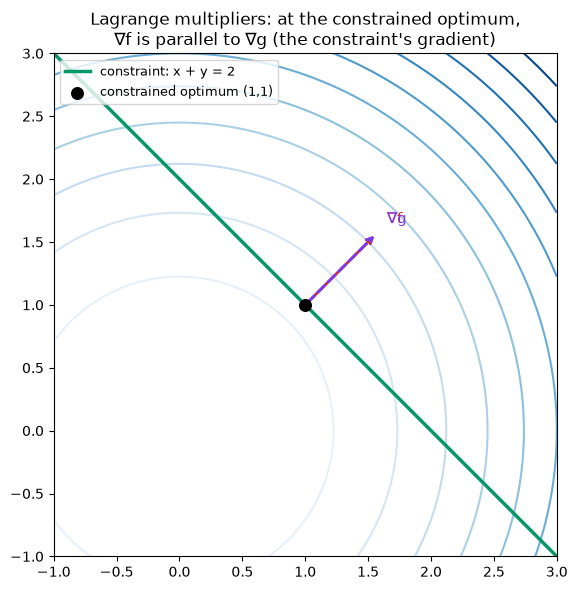

In [4]:
def visualize_lagrange(savepath: Path = None):
    # minimize f(x,y) = x^2 + y^2 subject to g(x,y) = x + y - 2 = 0
    xc = np.linspace(-1, 3, 200)
    yc = np.linspace(-1, 3, 200)
    Xc, Yc = np.meshgrid(xc, yc)
    Zc = Xc**2 + Yc**2

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.contour(Xc, Yc, Zc, levels=12, cmap="Blues")
    xl = np.linspace(-1, 3, 100)
    yl = 2 - xl
    ax.plot(xl, yl, color="#059669", linewidth=2.5, label="constraint: x + y = 2")

    opt = np.array([1.0, 1.0])   # solved via Lagrange conditions: x=y=1
    ax.scatter(*opt, color="black", zorder=5, s=70, label="constrained optimum (1,1)")

    grad_f_opt = 2 * opt
    grad_f_opt_normed = grad_f_opt / np.linalg.norm(grad_f_opt) * 0.8
    ax.annotate("", xy=opt + grad_f_opt_normed, xytext=opt,
                arrowprops=dict(arrowstyle="->", color="#dc2626", lw=2))
    ax.text(*(opt + grad_f_opt_normed * 1.15), "∇f", color="#dc2626", fontsize=11)

    grad_g = np.array([1.0, 1.0]) / np.sqrt(2) * 0.8
    ax.annotate("", xy=opt + grad_g, xytext=opt,
                arrowprops=dict(arrowstyle="->", color="#7c3aed", lw=2, linestyle="--"))
    ax.text(*(opt + grad_g * 1.15), "∇g", color="#7c3aed", fontsize=11)

    ax.set_aspect("equal")
    ax.legend(fontsize=9, loc="upper left")
    ax.set_title("Lagrange multipliers: at the constrained optimum,\n∇f is parallel to ∇g (the constraint's gradient)")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_lagrange(FIG_DIR / "lagrange_multipliers.png")

The black dot is the closest point on the constraint line to the origin (the unconstrained minimum of `x²+y²`). At that point, `∇f` (red) and `∇g` (purple, the constraint's gradient — always perpendicular to the constraint line) point in exactly the same direction. That parallelism condition, `∇f = λ∇g`, is the Lagrange multiplier equation.

**Why this matters for ML interviews specifically:** the derivation of the **SVM dual problem** goes through exactly this machinery (constrained optimization with inequality constraints, generalized via KKT conditions — the inequality-constraint extension of Lagrange multipliers). If you've ever wondered where the "support vectors" and the dual formulation in SVMs actually come from mathematically, this is it.

---

## Self-check before moving on

- [ ] I can write the gradient descent update rule and explain what the learning rate controls
- [ ] I can explain, using the trajectory picture, what happens with a learning rate that's too large
- [ ] I can define convexity and state why it guarantees gradient descent finds the global optimum
- [ ] I can explain why saddle points, not bad local minima, are the more relevant obstacle in deep learning
- [ ] I can state the geometric intuition behind Lagrange multipliers (∇f parallel to ∇g at the constrained optimum)

This closes out the Calculus subchapter. Next up: **Statistics** (probability, Bayes' theorem, MLE/MAP, hypothesis testing) — the third area from the original roadmap.